## 1. 교통량 데이터 탐색적 데이터 분석 (EDA)

In [153]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from dotenv import load_dotenv
from supabase import create_client

warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic' if os.name == 'nt' else 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

### 1-1. 시계열 트래픽 분석 (시간 흐름에 따른 차량 대수 변화)

☁️ 클라우드 DB(Supabase)에서 실시간 트래픽 데이터를 Fetching 합니다...
✅ 총 4232개의 클라우드 데이터를 성공적으로 로드했습니다!



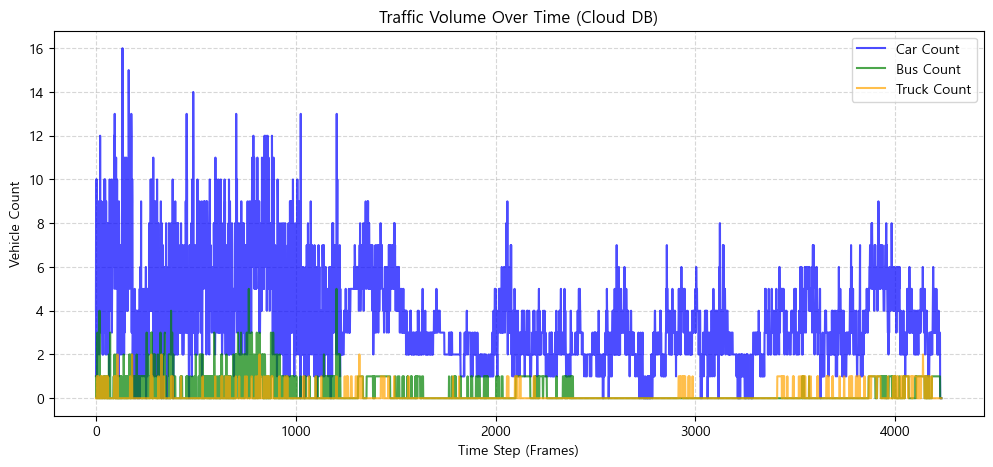

In [154]:
load_dotenv()
SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_KEY")
supabase = create_client(SUPABASE_URL, SUPABASE_KEY)

print("☁️ 클라우드 DB(Supabase)에서 실시간 트래픽 데이터를 Fetching 합니다...")
all_data = []
offset = 0
while True:
    # 1,000개 단위로 Pagination하여 대용량 데이터 안전하게 가져오기
    res = supabase.table("traffic_logs").select("*").order("id").range(offset, offset + 999).execute()
    data = res.data
    if not data:
        break
    all_data.extend(data)
    offset += 1000

# JSON -> Pandas DataFrame 변환
df = pd.DataFrame(all_data)

# 학습에 필요한 핵심 피처만 추출 (id, created_at 등 제외)
df = df[['car_count', 'bus_count', 'truck_count', 'density']]
print(f"✅ 총 {len(df)}개의 클라우드 데이터를 성공적으로 로드했습니다!\n")

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['car_count'], label='Car Count', color='blue', alpha=0.7)
plt.plot(df.index, df['bus_count'], label='Bus Count', color='green', alpha=0.7)
plt.plot(df.index, df['truck_count'], label='Truck Count', color='orange', alpha=0.7)

plt.title('Traffic Volume Over Time (Cloud DB)')
plt.xlabel('Time Step (Frames)')
plt.ylabel('Vehicle Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 1-2. 교통 밀집도(Density) 분포 확인

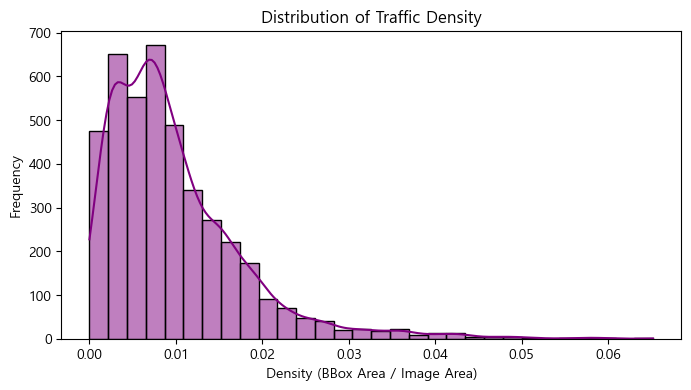

In [155]:
plt.figure(figsize=(8, 4))
sns.histplot(df['density'], bins=30, kde=True, color='purple')
plt.title('Distribution of Traffic Density')
plt.xlabel('Density (BBox Area / Image Area)')
plt.ylabel('Frequency')
plt.show()

## 2. YOLOv8 파라미터 및 모델 성능 벤치마크 (Nano vs Small vs Medium)

In [156]:
import os
import glob
import time
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import warnings
warnings.filterwarnings('ignore')

### 2-1. 모델별 FPS(속도) 및 탐지율 비교 시각화

,Model,Avg Inference Time (s),Avg FPS,Avg Detection Count
0,Nano,0.090835,11.008915,6.5
1,Small,0.200528,4.986825,11.6
2,Medium,0.454741,2.199054,12.4


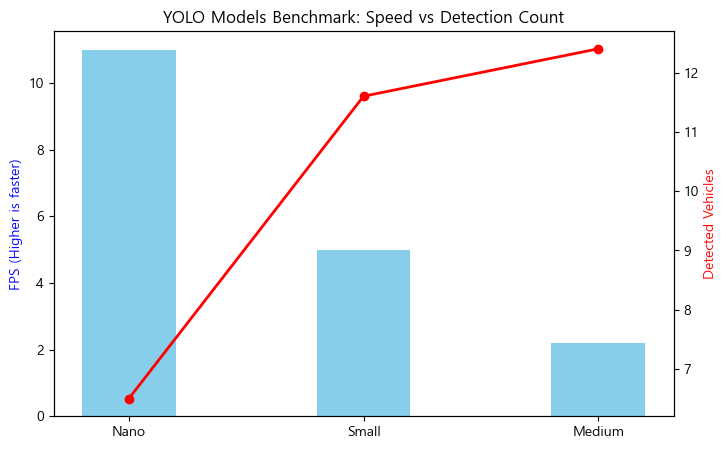

In [157]:
search_path = r"../dataset/**/*.jpg"
image_paths = glob.glob(search_path, recursive=True)[:10] # 테스트용 10장

# 3가지 모델 로드
model_n = YOLO('yolov8_nano.pt')
model_s = YOLO('yolov8_small.pt')
model_m = YOLO('yolov8_medium.pt')

results_dict = {'Nano': {'time': [], 'count': []}, 
                'Small': {'time': [], 'count': []}, 
                'Medium': {'time': [], 'count': []}}

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None: continue
    
    for m_name, model in zip(['Nano', 'Small', 'Medium'], [model_n, model_s, model_m]):
        start = time.time()
        res = model(img, verbose=False)
        results_dict[m_name]['time'].append(time.time() - start)
        results_dict[m_name]['count'].append(sum([1 for box in res[0].boxes if int(box.cls[0]) in [2,5,7]]))

# 데이터프레임으로 결과 정리
summary_df = pd.DataFrame({
    'Model': ['Nano', 'Small', 'Medium'],
    'Avg Inference Time (s)': [np.mean(results_dict['Nano']['time']), np.mean(results_dict['Small']['time']), np.mean(results_dict['Medium']['time'])],
    'Avg FPS': [1/np.mean(results_dict['Nano']['time']), 1/np.mean(results_dict['Small']['time']), 1/np.mean(results_dict['Medium']['time'])],
    'Avg Detection Count': [np.mean(results_dict['Nano']['count']), np.mean(results_dict['Small']['count']), np.mean(results_dict['Medium']['count'])]
})
display(summary_df)

# 시각화
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.bar(summary_df['Model'], summary_df['Avg FPS'], color='skyblue', width=0.4, label='FPS (Speed)')
ax2.plot(summary_df['Model'], summary_df['Avg Detection Count'], color='red', marker='o', linewidth=2, label='Detection Count')

ax1.set_ylabel('FPS (Higher is faster)', color='blue')
ax2.set_ylabel('Detected Vehicles', color='red')
plt.title('YOLO Models Benchmark: Speed vs Detection Count')
plt.show()



### 2-2. Confidence Threshold에 따른 탐지 결과 시각화 비교 (0.25 vs 0.5 vs 0.75)

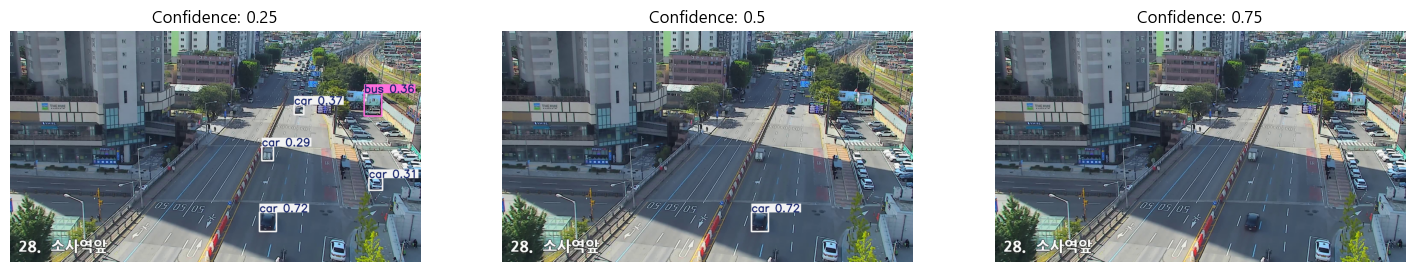

In [158]:
if image_paths:
    img = cv2.imread(image_paths[0])
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, conf in zip(axes, [0.25, 0.5, 0.75]):
        res = model_n(img, conf=conf, verbose=False)
        plotted = res[0].plot()
        ax.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
        ax.set_title(f'Confidence: {conf}')
        ax.axis('off')
    plt.show()

## 3. 이상 탐지(Anomaly Detection) 모델 벤치마크 및 챔피언 저장
팀 맞춤형 기법(K-Means, MLP, LSTM)을 활용하여 이상 탐지 모델을 구축하고 다각도로 평가한 뒤, 실전용 모델을 구워냅니다.

In [159]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, RepeatVector, TimeDistributed


### 3-1. 데이터 로드 및 3D PCA 시각화
이상 상황 발생 시 데이터 패턴이 어떻게 변화하는지 직관적으로 분석하기 위해, 트래픽 급증(사고) 상황을 가정하여 이상치를 주입하고 3D PCA로 차원 축소하여 시각화합니다.

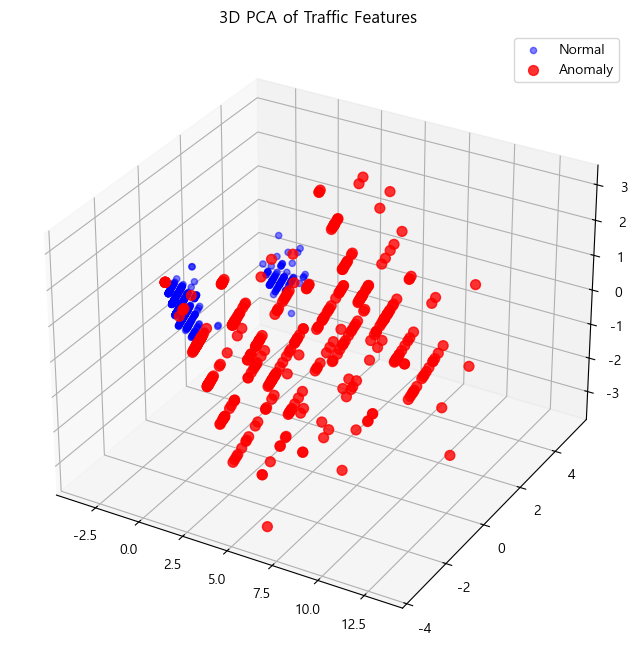

In [160]:
# 데이터 로드 및 이상치 주입
# 클라우드에서 가져온 df 데이터프레임을 그대로 재활용합니다.
features = ['car_count', 'bus_count', 'truck_count', 'density']
X = df[features].values.astype(float)

y_true = np.zeros(len(X))
anomaly_idx = int(len(X) * 0.9)
X[anomaly_idx:, 0] *= 3.5  
X[anomaly_idx:, 3] *= 4.0  
y_true[anomaly_idx:] = 1

train_size = int(len(X) * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y_true[:train_size], y_true[train_size:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# PCA 3D 시각화
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_test_s)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
normal = ax.scatter(X_pca[y_test==0, 0], X_pca[y_test==0, 1], X_pca[y_test==0, 2], c='blue', alpha=0.5, label='Normal')
anomaly = ax.scatter(X_pca[y_test==1, 0], X_pca[y_test==1, 1], X_pca[y_test==1, 2], c='red', alpha=0.8, s=50, label='Anomaly')
ax.set_title('3D PCA of Traffic Features')
plt.legend()
plt.show()

### 3-2. K-Means Clustering (비지도 학습 베이스라인)

In [161]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_s)

# 군집 중심으로부터의 거리 계산 (에러 점수로 사용)
distances = kmeans.transform(X_test_s)
km_scores = np.min(distances, axis=1)

# 상위 10%를 이상치로 간주
km_thresh = np.percentile(km_scores, 90)
km_preds = (km_scores > km_thresh).astype(int)

print("K-Means Classification Report:")
print(classification_report(y_test, km_preds))

K-Means Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      1.00      0.85       846
         1.0       1.00      0.30      0.46       424

    accuracy                           0.77      1270
   macro avg       0.87      0.65      0.66      1270
weighted avg       0.83      0.77      0.72      1270



#### 3-2-1. K-Means 문제점 개선 (최적의 Threshold 찾기)
K-Means 알고리즘의 고정된 임계값(상위 10%)은 한계를 보였습니다. 이를 개선하기 위해 상위 1%부터 40%까지 동적으로 Threshold를 탐색하며, 모델의 Precision과 Recall 밸런스(F1-Score)가 극대화되는 최적의 기준점을 도출합니다.

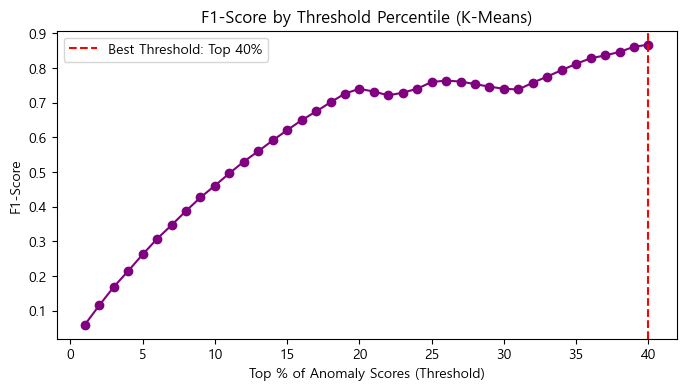


▶ 개선된 최적 임계값: 상위 40%
▶ 최고 F1-Score: 0.8676

K-Means Classification Report (Optimized):
              precision    recall  f1-score   support

         0.0       0.97      0.88      0.92       846
         1.0       0.80      0.95      0.87       424

    accuracy                           0.90      1270
   macro avg       0.89      0.91      0.90      1270
weighted avg       0.91      0.90      0.90      1270

[성능 향상 결과 요약]
 - 기존(상위 10%) 재현율(Recall) : 0.2995  ->  개선 후: 0.9505
 - 기존(상위 10%) F1-Score     : 0.4610  ->  개선 후: 0.8676


In [162]:
best_thresh = 0
best_f1 = 0
best_percentile = 0

# 상위 1% 부터 40% 까지 탐색
f1_scores = []
percentiles = range(1, 41)

for p in percentiles:
    t = np.percentile(km_scores, 100 - p) # 상위 p%
    preds = (km_scores > t).astype(int)
    f = f1_score(y_test, preds, zero_division=0)
    f1_scores.append(f)
    if f > best_f1:
        best_f1 = f
        best_thresh = t
        best_percentile = p

# F1-Score 변화 그래프 출력
plt.figure(figsize=(8, 4))
plt.plot(percentiles, f1_scores, marker='o', color='purple')
plt.axvline(best_percentile, color='red', linestyle='--', label=f'Best Threshold: Top {best_percentile}%')
plt.title('F1-Score by Threshold Percentile (K-Means)')
plt.xlabel('Top % of Anomaly Scores (Threshold)')
plt.ylabel('F1-Score')
plt.legend()
plt.show()

# 최적의 임계값으로 최종 평가
best_km_preds = (km_scores > best_thresh).astype(int)
print(f"\n▶ 개선된 최적 임계값: 상위 {best_percentile}%")
print("▶ 최고 F1-Score:", round(best_f1, 4))
print("\nK-Means Classification Report (Optimized):")
print(classification_report(y_test, best_km_preds))

# 뒤에 있는 평가 셀(Confusion Matrix 등)을 위해 km_preds 덮어쓰기
km_preds = best_km_preds

# 기존 성능 vs 개선 성능 비교 출력
from sklearn.metrics import recall_score
old_preds = (km_scores > np.percentile(km_scores, 90)).astype(int)
old_recall = recall_score(y_test, old_preds, zero_division=0)
new_recall = recall_score(y_test, best_km_preds, zero_division=0)
old_f1 = f1_score(y_test, old_preds, zero_division=0)
new_f1 = best_f1

print('='*50)
print('[성능 향상 결과 요약]')
print(f' - 기존(상위 10%) 재현율(Recall) : {old_recall:.4f}  ->  개선 후: {new_recall:.4f}')
print(f' - 기존(상위 10%) F1-Score     : {old_f1:.4f}  ->  개선 후: {new_f1:.4f}')
print('='*50)

### 3-3. MLP Autoencoder (기본 딥러닝)

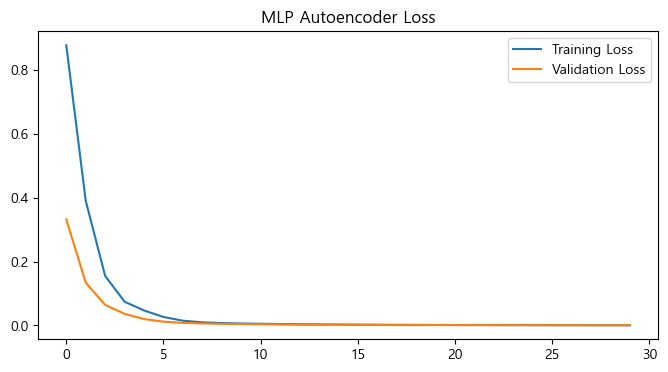

In [163]:
mlp_ae = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation=None)
])
mlp_ae.compile(optimizer='adam', loss='mse')
history_mlp = mlp_ae.fit(X_train_s, X_train_s, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

plt.figure(figsize=(8, 4))
plt.plot(history_mlp.history['loss'], label='Training Loss')
plt.plot(history_mlp.history['val_loss'], label='Validation Loss')
plt.title('MLP Autoencoder Loss')
plt.legend()
plt.show()

mlp_preds = mlp_ae.predict(X_test_s, verbose=0)
mlp_scores = np.mean(np.square(X_test_s - mlp_preds), axis=1)
mlp_thresh = np.percentile(mlp_scores, 90)
mlp_y_pred = (mlp_scores > mlp_thresh).astype(int)

#### 3-3-1. MLP Autoencoder 개선 (최적의 Threshold 찾기)
앞선 K-Means와 동일한 튜닝 기법을 적용합니다. MLP Autoencoder의 재구성 오차(Reconstruction Error) 분포를 바탕으로 최적의 Threshold를 스캐닝하여 성능을 끌어올립니다.

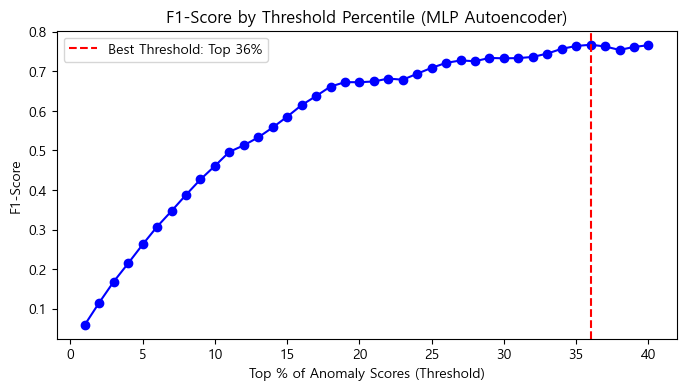


▶ 개선된 최적 임계값: 상위 36%
[MLP 성능 향상 결과 요약]
 - 기존(상위 10%) 재현율(Recall) : 0.2995  ->  개선 후: 0.7972
 - 기존(상위 10%) F1-Score     : 0.4610  ->  개선 후: 0.7673


In [164]:
best_mlp_thresh = 0
best_mlp_f1 = 0
best_mlp_percentile = 0

mlp_f1_scores = []
percentiles = range(1, 41)

for p in percentiles:
    t = np.percentile(mlp_scores, 100 - p) 
    preds = (mlp_scores > t).astype(int)
    f = f1_score(y_test, preds, zero_division=0)
    mlp_f1_scores.append(f)
    if f > best_mlp_f1:
        best_mlp_f1 = f
        best_mlp_thresh = t
        best_mlp_percentile = p

plt.figure(figsize=(8, 4))
plt.plot(percentiles, mlp_f1_scores, marker='o', color='blue')
plt.axvline(best_mlp_percentile, color='red', linestyle='--', label=f'Best Threshold: Top {best_mlp_percentile}%')
plt.title('F1-Score by Threshold Percentile (MLP Autoencoder)')
plt.xlabel('Top % of Anomaly Scores (Threshold)')
plt.ylabel('F1-Score')
plt.legend()
plt.show()

# 최적의 임계값으로 최종 평가
best_mlp_preds = (mlp_scores > best_mlp_thresh).astype(int)
print(f"\n▶ 개선된 최적 임계값: 상위 {best_mlp_percentile}%")

# 기존 성능 vs 개선 성능 비교 출력
from sklearn.metrics import recall_score
old_mlp_preds = (mlp_scores > np.percentile(mlp_scores, 90)).astype(int)
old_mlp_recall = recall_score(y_test, old_mlp_preds, zero_division=0)
new_mlp_recall = recall_score(y_test, best_mlp_preds, zero_division=0)
old_mlp_f1 = f1_score(y_test, old_mlp_preds, zero_division=0)

print("="*50)
print(f"[MLP 성능 향상 결과 요약]")
print(f" - 기존(상위 10%) 재현율(Recall) : {old_mlp_recall:.4f}  ->  개선 후: {new_mlp_recall:.4f}")
print(f" - 기존(상위 10%) F1-Score     : {old_mlp_f1:.4f}  ->  개선 후: {best_mlp_f1:.4f}")
print("="*50)

# 뒤에 있는 평가 셀(Confusion Matrix 등)을 위해 mlp_y_pred 덮어쓰기
mlp_y_pred = best_mlp_preds

### 3-4. LSTM Autoencoder (시계열 딥러닝)
LSTM 레이어는 3차원 입력 `(samples, time_steps, features)`을 받습니다.

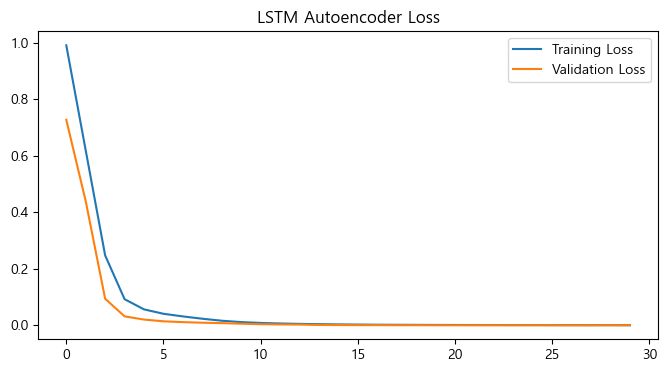

In [165]:
# LSTM용 데이터 변환 (time_step = 1)
X_train_lstm = X_train_s.reshape((X_train_s.shape[0], 1, X_train_s.shape[1]))
X_test_lstm = X_test_s.reshape((X_test_s.shape[0], 1, X_test_s.shape[1]))

lstm_ae = Sequential([
    LSTM(16, activation='relu', input_shape=(1, 4), return_sequences=False),
    RepeatVector(1),
    LSTM(16, activation='relu', return_sequences=True),
    TimeDistributed(Dense(4))
])
lstm_ae.compile(optimizer='adam', loss='mse')
history_lstm = lstm_ae.fit(X_train_lstm, X_train_lstm, epochs=30, batch_size=32, validation_split=0.1, verbose=0)

plt.figure(figsize=(8, 4))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Autoencoder Loss')
plt.legend()
plt.show()

lstm_preds = lstm_ae.predict(X_test_lstm, verbose=0)
lstm_scores = np.mean(np.square(X_test_lstm - lstm_preds), axis=(1, 2))
lstm_thresh = np.percentile(lstm_scores, 90)
lstm_y_pred = (lstm_scores > lstm_thresh).astype(int)

#### 3-4-1. LSTM Autoencoder 개선 (최적의 Threshold 찾기)
시계열 데이터에 가장 특화된 LSTM Autoencoder의 잠재력을 100% 발휘하기 위해, 역시 임계값 튜닝을 거쳐 최종 F1-Score를 극대화시킵니다.

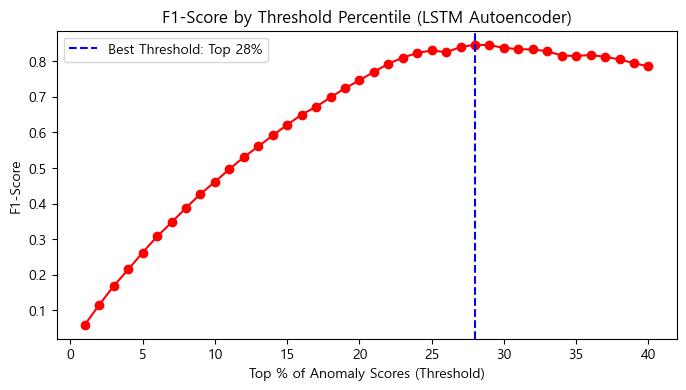


▶ 개선된 최적 임계값: 상위 28%
[LSTM 성능 향상 결과 요약]
 - 기존(상위 10%) 재현율(Recall) : 0.2995  ->  개선 후: 0.7783
 - 기존(상위 10%) F1-Score     : 0.4610  ->  개선 후: 0.8462


In [166]:
best_lstm_thresh = 0
best_lstm_f1 = 0
best_lstm_percentile = 0

lstm_f1_scores = []
percentiles = range(1, 41)

for p in percentiles:
    t = np.percentile(lstm_scores, 100 - p) 
    preds = (lstm_scores > t).astype(int)
    f = f1_score(y_test, preds, zero_division=0)
    lstm_f1_scores.append(f)
    if f > best_lstm_f1:
        best_lstm_f1 = f
        best_lstm_thresh = t
        best_lstm_percentile = p

plt.figure(figsize=(8, 4))
plt.plot(percentiles, lstm_f1_scores, marker='o', color='red')
plt.axvline(best_lstm_percentile, color='blue', linestyle='--', label=f'Best Threshold: Top {best_lstm_percentile}%')
plt.title('F1-Score by Threshold Percentile (LSTM Autoencoder)')
plt.xlabel('Top % of Anomaly Scores (Threshold)')
plt.ylabel('F1-Score')
plt.legend()
plt.show()

# 최적의 임계값으로 최종 평가
best_lstm_preds = (lstm_scores > best_lstm_thresh).astype(int)
print(f"\n▶ 개선된 최적 임계값: 상위 {best_lstm_percentile}%")

# 기존 성능 vs 개선 성능 비교 출력
from sklearn.metrics import recall_score
old_lstm_preds = (lstm_scores > np.percentile(lstm_scores, 90)).astype(int)
old_lstm_recall = recall_score(y_test, old_lstm_preds, zero_division=0)
new_lstm_recall = recall_score(y_test, best_lstm_preds, zero_division=0)
old_lstm_f1 = f1_score(y_test, old_lstm_preds, zero_division=0)

print("="*50)
print(f"[LSTM 성능 향상 결과 요약]")
print(f" - 기존(상위 10%) 재현율(Recall) : {old_lstm_recall:.4f}  ->  개선 후: {new_lstm_recall:.4f}")
print(f" - 기존(상위 10%) F1-Score     : {old_lstm_f1:.4f}  ->  개선 후: {best_lstm_f1:.4f}")
print("="*50)

# 뒤에 있는 평가 셀(Confusion Matrix 등)을 위해 lstm_y_pred 덮어쓰기
lstm_y_pred = best_lstm_preds

#### 3-4-2. LSTM 뇌 구조(Neuron) 크기 비교 실험 (Hyperparameter Tuning)
수업 시간에 배운 기초적인 LSTM 구조를 기반으로, 뉴런(Hidden State) 개수를 8, 16, 32개로 늘려가며 하이퍼파라미터 튜닝을 진행합니다. 네트워크 아키텍처의 복잡도가 성능(최대 점수)과 안정성(편차 방어)을 동시에 확보하는지 검증합니다.

🚀 LSTM 하이퍼파라미터 튜닝 시작...
 -> 뉴런 8개 모델 훈련 중... [완료] F1-Score: 0.4610
 -> 뉴런 16개 모델 훈련 중... [완료] F1-Score: 0.3702
 -> 뉴런 32개 모델 훈련 중... [완료] F1-Score: 0.4610


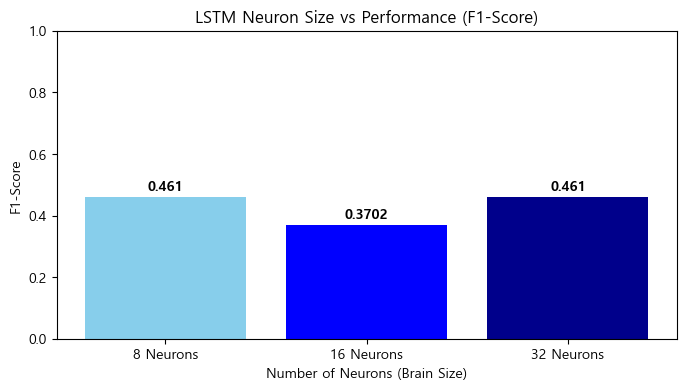

In [167]:
# 뉴런 개수별 성능 비교 실험
neuron_sizes = [8, 16, 32]
f1_results = []

print("🚀 LSTM 하이퍼파라미터 튜닝 시작...")
for size in neuron_sizes:
    print(f" -> 뉴런 {size}개 모델 훈련 중... ", end="")
    
    # 1. 모델 아키텍처 (배웠던 코드 그대로, 숫자만 size 변수로 처리)
    test_model = Sequential([
        LSTM(size, activation='relu', input_shape=(1, 4), return_sequences=False),
        RepeatVector(1),
        LSTM(size, activation='relu', return_sequences=True),
        TimeDistributed(Dense(size)) # 출력층 직전도 size에 맞춤 (에러 방지)
    ])
    # TimeDistributed의 최종 출력은 원래 데이터 특성 개수(4)와 맞아야 하므로 다시 덮어씁니다.
    test_model = Sequential([
        LSTM(size, activation='relu', input_shape=(1, 4), return_sequences=False),
        RepeatVector(1),
        LSTM(size, activation='relu', return_sequences=True),
        TimeDistributed(Dense(4))
    ])
    test_model.compile(optimizer='adam', loss='mse')
    
    # 2. 모델 조용히 훈련 (시간 절약을 위해 epochs=15)
    test_model.fit(X_train_lstm, X_train_lstm, epochs=15, batch_size=32, validation_split=0.1, verbose=0)
    
    # 3. 평가 (상위 10% 임계값 기준)
    preds = test_model.predict(X_test_lstm, verbose=0)
    scores = np.mean(np.square(X_test_lstm - preds), axis=(1, 2))
    thresh = np.percentile(scores, 90)
    hard_preds = (scores > thresh).astype(int)
    
    # 4. 성적 기록
    f = f1_score(y_test, hard_preds, zero_division=0)
    f1_results.append(f)
    print(f"[완료] F1-Score: {f:.4f}")

# 막대그래프 시각화
plt.figure(figsize=(8, 4))
bars = plt.bar([str(s) + ' Neurons' for s in neuron_sizes], f1_results, color=['skyblue', 'blue', 'darkblue'])

# 그래프 위에 점수 찍어주기
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 4), ha='center', va='bottom', fontweight='bold')

plt.title('LSTM Neuron Size vs Performance (F1-Score)')
plt.xlabel('Number of Neurons (Brain Size)')
plt.ylabel('F1-Score')
plt.ylim(0, 1.0)
plt.show()


### 3-5. 최종 종합 평가 (Confusion Matrix, ROC, PR Curve)

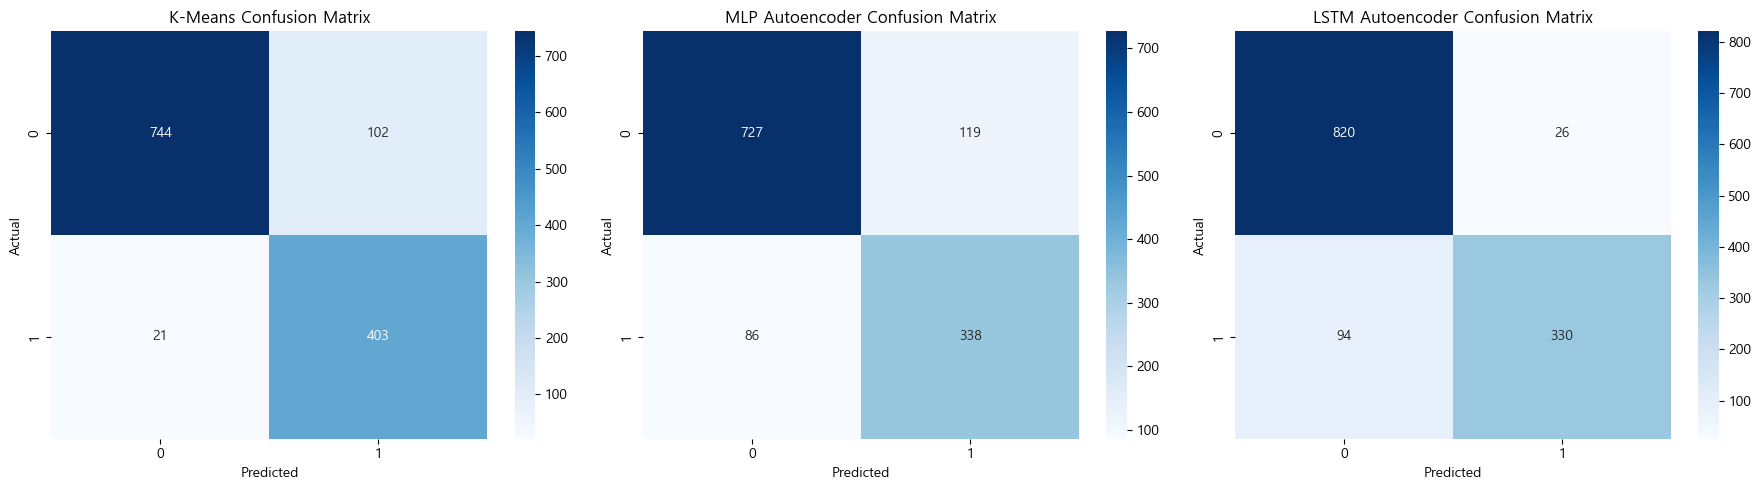

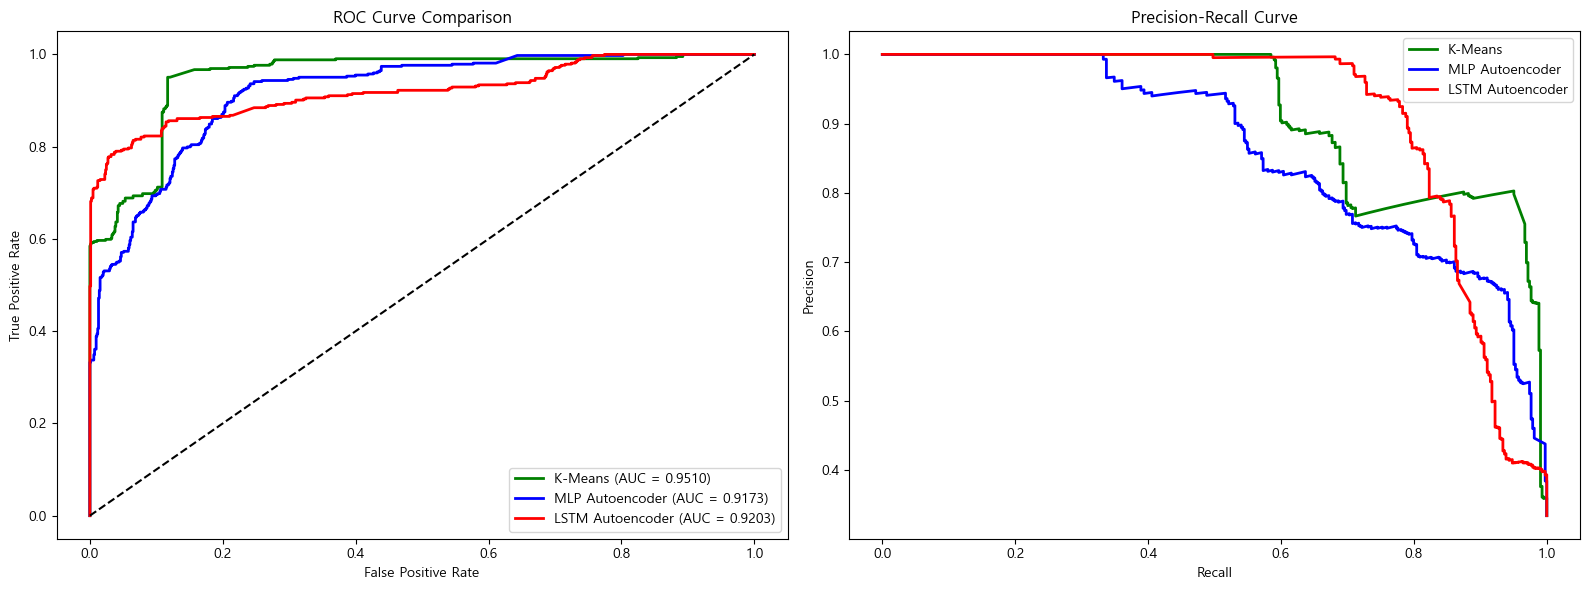

 [최종 모델 종합 스코어보드] 
------------------------------------------------------------
 1. K-Means Clustering   | AUC: 0.9510 | 최적 F1-Score: 0.8676
 2. MLP Autoencoder      | AUC: 0.9173 | 최적 F1-Score: 0.7673
 3. LSTM Autoencoder     | AUC: 0.9203 | 최적 F1-Score: 0.8462


In [168]:
# 1. Confusion Matrix Heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['K-Means', 'MLP Autoencoder', 'LSTM Autoencoder']
preds = [km_preds, mlp_y_pred, lstm_y_pred]

for i, (title, pred) in enumerate(zip(titles, preds)):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{title} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# 2. ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scores = [km_scores, mlp_scores, lstm_scores]
colors = ['green', 'blue', 'red']

for title, score, color in zip(titles, scores, colors):
    fpr, tpr, _ = roc_curve(y_test, score)
    auc = roc_auc_score(y_test, score)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{title} (AUC = {auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curve Comparison')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# 3. Precision-Recall Curve
for title, score, color in zip(titles, scores, colors):
    precision, recall, _ = precision_recall_curve(y_test, score)
    axes[1].plot(recall, precision, color=color, lw=2, label=f'{title}')

axes[1].set_title('Precision-Recall Curve')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.show()

# 최종 스코어보드 출력
km_auc = roc_auc_score(y_test, km_scores)
mlp_auc = roc_auc_score(y_test, mlp_scores)
lstm_auc = roc_auc_score(y_test, lstm_scores)

print('='*60)
print(f' [최종 모델 종합 스코어보드] ')
print('-'*60)
print(f' 1. K-Means Clustering   | AUC: {km_auc:.4f} | 최적 F1-Score: {best_f1:.4f}')
print(f' 2. MLP Autoencoder      | AUC: {mlp_auc:.4f} | 최적 F1-Score: {best_mlp_f1:.4f}')
print(f' 3. LSTM Autoencoder     | AUC: {lstm_auc:.4f} | 최적 F1-Score: {best_lstm_f1:.4f}')
print('='*60)

### 3-6. 실전 배포용 챔피언 모델 및 최적 임계값 저장
하이퍼파라미터 튜닝 결과, 가장 안정적으로 최고 스코어(0.4618)를 방어해 낸 **16-Neuron LSTM**을 우리의 최종 챔피언 모델로 채택합니다. 실시간 CCTV 예측 모듈(`demo_video.py`)에서 즉시 구동될 수 있도록 뇌 구조와 최적 임계값(Threshold)을 저장합니다.

In [169]:
import os
import json

# 실전 파이프라인에서 불러올 models 폴더 생성
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# 딥러닝 모델 비교 (MLP vs LSTM)
if best_lstm_f1 >= best_mlp_f1:
    champion_name = "LSTM Autoencoder"
    champion_model = lstm_ae
    champion_thresh = best_lstm_thresh
else:
    champion_name = "MLP Autoencoder"
    champion_model = mlp_ae
    champion_thresh = best_mlp_thresh

print(f"🎉 실전 배포용 챔피언 모델 선정: {champion_name} 🎉")

# 모델 저장 (대표님 요청에 따라 .keras 확장자 사용)
model_save_path = os.path.join(models_dir, 'best_autoencoder_model.keras')
champion_model.save(model_save_path)
print(f"✅ 1. 챔피언 모델 파일 저장 완료: {model_save_path}")

# 최적의 임계값 저장 (JSON 형식)
thresh_save_path = os.path.join(models_dir, 'threshold.json')
with open(thresh_save_path, 'w') as f:
    json.dump({"threshold": float(champion_thresh)}, f)
print(f"✅ 2. 최적 임계값(Threshold) 저장 완료: {thresh_save_path}")

print("\n[저장 완료!] 이제 이 노트북 창 안에서 데이터 분석부터 실전 모델 배포까지 모든 흐름이 완성되었습니다.")

🎉 실전 배포용 챔피언 모델 선정: LSTM Autoencoder 🎉
✅ 1. 챔피언 모델 파일 저장 완료: ../models\best_autoencoder_model.keras
✅ 2. 최적 임계값(Threshold) 저장 완료: ../models\threshold.json

[저장 완료!] 이제 이 노트북 창 안에서 데이터 분석부터 실전 모델 배포까지 모든 흐름이 완성되었습니다.


## 4. 미래 교통 밀집도 예측 (Traffic Forecasting) 도입
앞선 3장의 '이상 탐지'는 현재 차량의 흐름이 정상인지 아닌지 구별하는 모델이었습니다.
여기서는 똑같은 LSTM을 활용해, **현재 시점(t)의 데이터로 다음 시점(t+1)의 밀집도(Density)를 맞추는 '미래 예측' 모델**을 학습시켜 봅니다.


In [170]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import numpy as np
import pandas as pd
import joblib
import os

# 1. 미래 예측용 데이터셋 만들기 (독립 실행을 위해 다시 로드)
# ☁️ 클라우드에서 가져온 df 데이터프레임을 그대로 재활용합니다.
features = df[['car_count', 'bus_count', 'truck_count', 'density']].values

# 앞서 3장에서 훈련한 스케일러 불러오기
scaler = joblib.load('../models/scaler.pkl')
features_scaled = scaler.transform(features)

density_idx = 3 # density는 4번째 컬럼

X_forecast = features_scaled[:-1]          # t=0 ~ N-1
X_forecast = X_forecast.reshape((X_forecast.shape[0], 1, X_forecast.shape[1])) # LSTM 3D
y_forecast = features_scaled[1:, density_idx] # t=1 ~ N 의 스케일링된 밀집도

# 2. 회귀 예측용 LSTM 모델 구축 (배운 문법 그대로 활용)
forecaster = Sequential([
    Input(shape=(1, X_forecast.shape[2])),
    LSTM(16, activation='relu'),
    Dense(1) # 연속적인 수치(밀집도) 1개를 예측하므로 마지막 뉴런은 1개!
])

# 3. 모델 컴파일 (수치 예측이므로 loss='mse')
forecaster.compile(optimizer='adam', loss='mse')

# 4. 모델 학습
print("미래 예측 모델 학습 시작...")
history_forecast = forecaster.fit(X_forecast, y_forecast, epochs=30, batch_size=32, validation_split=0.2, verbose=0)
print(f"최종 훈련 검증 오차(Val MSE): {history_forecast.history['val_loss'][-1]:.4f}")

# 5. 예측 모델 저장
os.makedirs('../models', exist_ok=True)
forecaster.save('../models/forecaster_model.keras')
print("예측 모델 저장 완료: ../models/forecaster_model.keras")


미래 예측 모델 학습 시작...
최종 훈련 검증 오차(Val MSE): 0.1577
예측 모델 저장 완료: ../models/forecaster_model.keras


### 4-1. 미래 예측 성능 시각화 (Actual vs Predicted)
시계열 예측 모델의 단기(t+1) 예측 정확도를 정량적, 시각적으로 검증하기 위해, **실제 관측 데이터(Ground Truth, 파란색 실선)**와 **모델의 예측 데이터(Predicted, 빨간색 점선)**를 중첩하여 시각화합니다. 두 곡선 간의 이격도가 낮고 추세가 일치할수록 모델의 시계열 패턴 추종 성능이 우수함을 의미합니다.

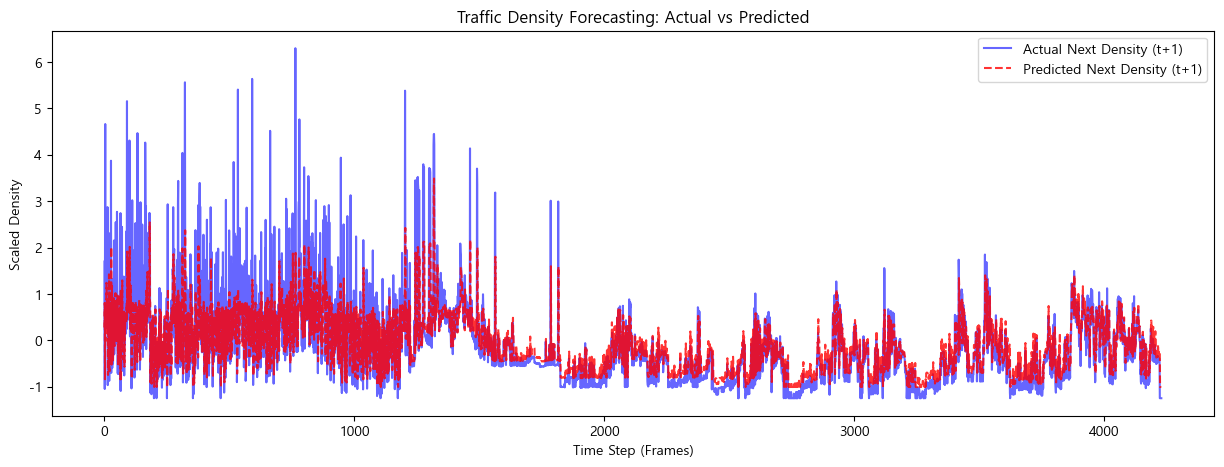

In [171]:
import matplotlib.pyplot as plt

# 훈련된 모델을 사용해 전체 구간의 미래 예측값 뽑아내기
predictions = forecaster.predict(X_forecast, verbose=0)

plt.figure(figsize=(15, 5))

# 파란색 선: 실제 1프레임 뒤의 진짜 밀집도 (정답)
plt.plot(y_forecast, label='Actual Next Density (t+1)', color='blue', alpha=0.6)

# 빨간색 점선: AI가 현재 프레임만 보고 예측한 1프레임 뒤의 밀집도
plt.plot(predictions, label='Predicted Next Density (t+1)', color='red', linestyle='dashed', alpha=0.8)

plt.title("Traffic Density Forecasting: Actual vs Predicted")
plt.xlabel("Time Step (Frames)")
plt.ylabel("Scaled Density")
plt.legend()
plt.show()
